In [3]:
!pip install ultralytics roboflow opencv-python


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 135.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [4]:
from ultralytics import YOLO
from roboflow import Roboflow
import cv2
import matplotlib.pyplot as plt


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="yELJu2gw75lsXWARqaIv")
project = rf.workspace("hardhatdetection-pq5cy").project("hard-hat-sample-zz4je")
version = project.version(1)
dataset = version.download("yolov8")



loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Hard-Hat-Sample-1 in yolov8:: 100%|██████████| 212/212 [00:00<00:00, 9612.27it/s]


In [6]:
from ultralytics import YOLO

# Load a pretrained YOLOv8n (nano) model — small and fast
model = YOLO('yolov8n.pt')


In [7]:
!ls /content


Hard-Hat-Sample-1  sample_data	yolov8n.pt


In [8]:
# Train the YOLOv8 model
model.train(
    data="/content/Hard-Hat-Sample-1/data.yaml",  # check this path if folder name differs
    epochs=30,
    imgsz=640,
    batch=16
)


Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Hard-Hat-Sample-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7de7e57542c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [10]:
# # Load trained model
# # model = YOLO("runs/detect/train/weights/best.pt")

# # Upload a test image
# from google.colab import files
# uploaded = files.upload()

# # Run prediction
# test_image = list(uploaded.keys())[0]
# results = model.predict(source=test_image, show=True, conf=0.4)


In [11]:
# Load the trained YOLOv8 model
model = YOLO("runs/detect/train/weights/best.pt")


In [12]:
!ls /content/Hard-Hat-Sample-1/test/images | head


000008_jpg.rf.46f3cbf800362006302db1cf3a30dc3d.jpg
000011_jpg.rf.c9e180d72aaa57a75a50a61f5bb057f6.jpg
000034_jpg.rf.3767040f645f5241b23fa0b84a410b7e.jpg
000047_jpg.rf.1f19011b04f17c17bd8fff765a9de0df.jpg
000054_jpg.rf.4bbf9da2a145add8886518ff374646da.jpg
000073_jpg.rf.843e7af4732d3f18156a89cfb1f90e42.jpg
000076_jpg.rf.d41ee54b310a784995669ef5397c1650.jpg
000084_jpg.rf.857a41e9176965ac385eb59ce587817b.jpg
000097_jpg.rf.d79aa3ad67d7162e89a8cfa3b7768df5.jpg
000098_jpg.rf.c85867bbe44048518de2e4940c35ae1f.jpg



image 1/1 /content/Hard-Hat-Sample-1/test/images/000008_jpg.rf.46f3cbf800362006302db1cf3a30dc3d.jpg: 640x480 2 helmets, 8.1ms
Speed: 2.4ms preprocess, 8.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict


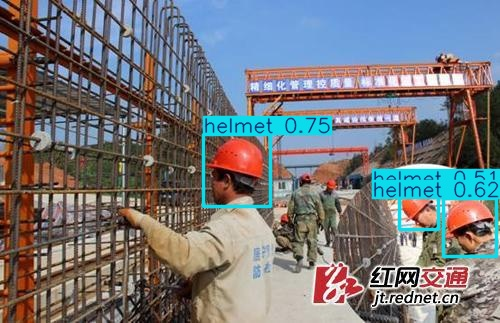

✅ Output image saved at: runs/detect/predict/000047_jpg.rf.1f19011b04f17c17bd8fff765a9de0df.jpg


In [26]:
#Checks only for 1 image
from ultralytics import YOLO
from IPython.display import Image, display
import glob

# Run prediction silently and save output
results = model.predict(
    source="/content/Hard-Hat-Sample-1/test/images/000008_jpg.rf.46f3cbf800362006302db1cf3a30dc3d.jpg",
    conf=0.4,
    show=False,   # 👈 very important in Colab
    save=True
)

# Find the latest prediction image automatically
latest_folder = sorted(glob.glob("runs/detect/predict*"))[-1]
predicted_image = glob.glob(f"{latest_folder}/*.jpg")[0]

# Display it inside Colab
display(Image(filename=predicted_image))
print(f"✅ Output image saved at: {predicted_image}")



🔹 Predicting: 000047_jpg.rf.1f19011b04f17c17bd8fff765a9de0df.jpg

image 1/1 /content/Hard-Hat-Sample-1/test/images/000047_jpg.rf.1f19011b04f17c17bd8fff765a9de0df.jpg: 416x640 3 helmets, 9.1ms
Speed: 2.3ms preprocess, 9.1ms inference, 1.3ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/runs/detect/predict


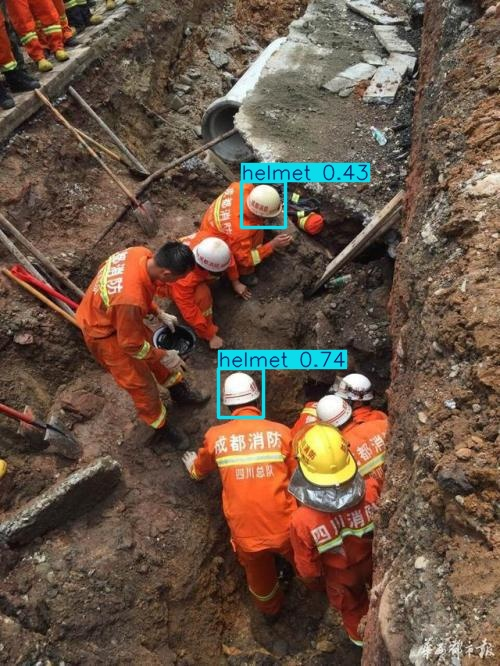


🔹 Predicting: 000054_jpg.rf.4bbf9da2a145add8886518ff374646da.jpg

image 1/1 /content/Hard-Hat-Sample-1/test/images/000054_jpg.rf.4bbf9da2a145add8886518ff374646da.jpg: 448x640 1 helmet, 9.1ms
Speed: 7.2ms preprocess, 9.1ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict


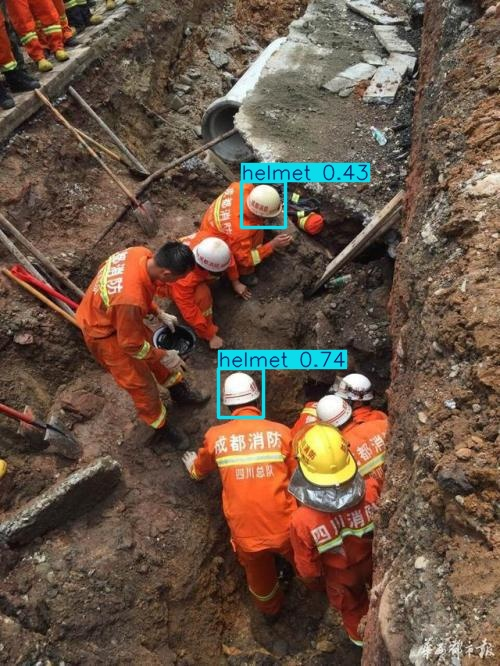


🔹 Predicting: 000076_jpg.rf.d41ee54b310a784995669ef5397c1650.jpg

image 1/1 /content/Hard-Hat-Sample-1/test/images/000076_jpg.rf.d41ee54b310a784995669ef5397c1650.jpg: 480x640 1 helmet, 8.9ms
Speed: 4.0ms preprocess, 8.9ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict


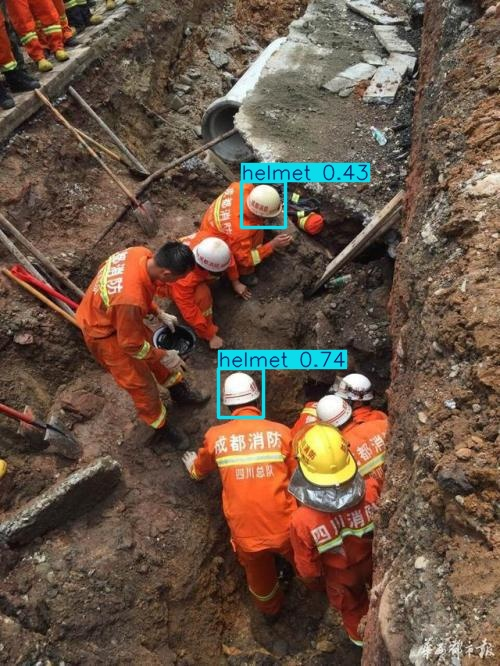


🔹 Predicting: 000011_jpg.rf.c9e180d72aaa57a75a50a61f5bb057f6.jpg

image 1/1 /content/Hard-Hat-Sample-1/test/images/000011_jpg.rf.c9e180d72aaa57a75a50a61f5bb057f6.jpg: 480x640 14 helmets, 9.2ms
Speed: 2.4ms preprocess, 9.2ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict


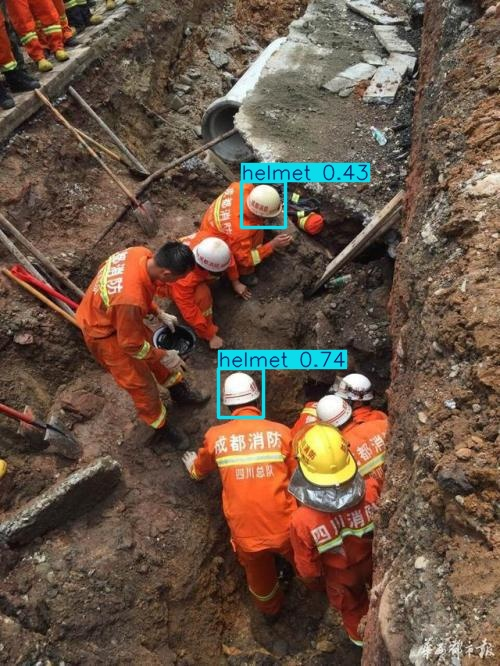


🔹 Predicting: 000084_jpg.rf.857a41e9176965ac385eb59ce587817b.jpg

image 1/1 /content/Hard-Hat-Sample-1/test/images/000084_jpg.rf.857a41e9176965ac385eb59ce587817b.jpg: 448x640 8 helmets, 10.3ms
Speed: 2.4ms preprocess, 10.3ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict


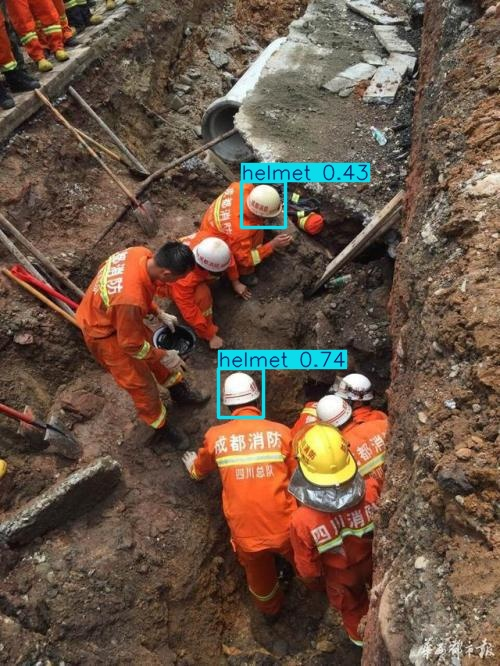

In [27]:
#checks for multiple images
import os, glob
from IPython.display import Image, display

test_dir = "/content/Hard-Hat-Sample-1/test/images"
test_images = os.listdir(test_dir)[:5]  # change 5 → 10 if you want more

for img_name in test_images:
    img_path = os.path.join(test_dir, img_name)
    print(f"\n🔹 Predicting: {img_name}")

    results = model.predict(
        source=img_path,
        conf=0.4,
        show=False,
        save=True
    )

    # Find the latest saved prediction
    latest_folder = sorted(glob.glob("runs/detect/predict*"))[-1]
    predicted_image = glob.glob(f"{latest_folder}/*.jpg")[-1]

    # Display inside Colab
    display(Image(filename=predicted_image))


In [28]:
metrics = model.val()
print(metrics)


Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1071.7±342.6 MB/s, size: 25.4 KB)
val: Scanning /content/Hard-Hat-Sample-1/valid/labels.cache... 20 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20/20 46.8Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.3it/s 0.9s
                   all         20         65      0.931      0.592      0.631      0.429
                  head          3         18      0.938      0.843      0.958      0.606
                helmet         17         45      0.855      0.933      0.932      0.678
                person          1          2          1          0    0.00387    0.00193
Speed: 5.4ms preprocess, 17.4ms inference, 0.0ms loss, 4.5ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 

In [29]:
import random, time

print(" Smart Factory Sensor Simulation\n")

for i in range(5):
    temperature = round(random.uniform(25, 45), 2)
    gas_level = round(random.uniform(150, 400), 2)

    if temperature > 40 or gas_level > 350:
        print(f"⚠️ ALERT! Unsafe Environment | Temp: {temperature}°C | Gas: {gas_level} ppm")
    else:
        print(f"Safe Environment | Temp: {temperature}°C | Gas: {gas_level} ppm")

    time.sleep(1)


 Smart Factory Sensor Simulation

Safe Environment | Temp: 37.37°C | Gas: 212.63 ppm
⚠️ ALERT! Unsafe Environment | Temp: 43.19°C | Gas: 395.7 ppm
⚠️ ALERT! Unsafe Environment | Temp: 41.2°C | Gas: 375.54 ppm
Safe Environment | Temp: 31.2°C | Gas: 332.46 ppm
⚠️ ALERT! Unsafe Environment | Temp: 42.98°C | Gas: 321.0 ppm
